In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

In [2]:
# General stochastic generation (CoSMoS_py) — discharge, temperature, ...
from pyhydra.climate.stochastic_generation import (
    analyze_ts,
    report_ts,
    simulate_ts,
    generate_ts,
    fit_distribution,
    fit_acs,
)

# Precipitation stochastic generation (NEOPRENE NSRP)
from pyhydra.climate.stochastic_generation import NSRPModel, STNSRPModel

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Stochastic Time Series Generation

This notebook demonstrates two complementary approaches to stochastic time series generation in `pyhydra`:

| Approach | Model | Variables | Library |
|----------|-------|-----------|---------|
| **General** | Seasonal stochastic (CoSMoS) | Any hydro-meteorological variable | CoSMoS_py |
| **Precipitation** | Neyman-Scott Rectangular Pulses (NSRP) | Precipitation only | NEOPRENE |

---

### What is stochastic generation?

A **stochastic generator** produces synthetic time series that are statistically equivalent to an observed record. They are not forecasts — they preserve the statistical structure (distribution, autocorrelation, seasonality) but generate new random sequences. Key applications:

- **Uncertainty quantification** — generate ensembles to propagate input uncertainty through hydrological models
- **Record extension** — produce long synthetic records from short observed ones (e.g. 30 observed years → 1000 synthetic years)
- **Climate stress testing** — perturb observed statistics to represent future or hypothetical conditions

---

### Installation

```bash
# CoSMoS_py (required for Section 1)
pip install -e /path/to/CoSMoS_py
# Source: https://github.com/navass11/CoSMoS_py

# NEOPRENE (optional — required for Sections 2 & 3)
pip install NEOPRENE
# Source: https://github.com/IHCantabria/NEOPRENE
```

---
## 1. General stochastic generation — CoSMoS_py

CoSMoS implements a **seasonal VAR(p) + ACTF** (AutoCorrelation Transformation Function) model (Papalexiou & Serinaldi 2020). The workflow is:

1. Fit a **marginal distribution** per month (`fit_distribution`)
2. Fit an **autocorrelation structure** (ACS) per month — Weibull ACF: $r(h) = e^{-(h/s)^{\kappa}}$
3. Combine into a **seasonal stochastic model** (`analyze_ts`)
4. Generate synthetic realisations (`simulate_ts` / `generate_ts`)

### Workflow

| Step | Function | Key parameters | Output |
|------|----------|---------------|--------|
| 1. Fit distribution | `fit_distribution(series, dist='gengamma')` | `dist` | params dict |
| 2. Fit ACS | `fit_acs(series, lag_max=8)` | `lag_max` | 12 × `{scale, shape}` |
| 3. Seasonal model | `analyze_ts(series)` | `dist`, `acs_id` | stats dict |
| 4. Single realisation | `simulate_ts(ts_stats, from_date, to_date)` | date range | DataFrame |
| 5. Ensemble | `generate_ts(n, dist, params, acs, p0, n_series)` | `n_series` | list of arrays |

### Key parameters

| Parameter | Description | Typical value |
|-----------|-------------|--------------|
| `dist` | Marginal distribution (`gengamma`, `gamma`, `lognorm`, `norm`) | `gengamma` for discharge |
| `acs_id` | ACS model (`weibull`, `exponential`) | `weibull` |
| `lag_max` | Max lag for ACS fitting — higher = longer memory but noisier fit | 8 for daily data |
| `p0` | Zero-probability (intermittency) — set 0 for continuous variables | 0 for discharge, 0.6–0.8 for precipitation |
| `n_series` | Number of synthetic realisations in ensemble | 50–1000 |

### Synthetic data

Below we create a realistic synthetic discharge series with **seasonal mean** and **AR(1) temporal persistence** ($\rho=0.7$), representative of a mid-latitude river. This serves as the "observed" record throughout this section.

Period            : 1990-01-01 → 2019-12-31
Mean Q            : 29.83 m³/s
Std  Q            : 16.08 m³/s
Global lag-1 ACF  : 0.927  (inflated by seasonality)
Detrended lag-1   : 0.698  (AR(1) noise ρ ≈ 0.70)


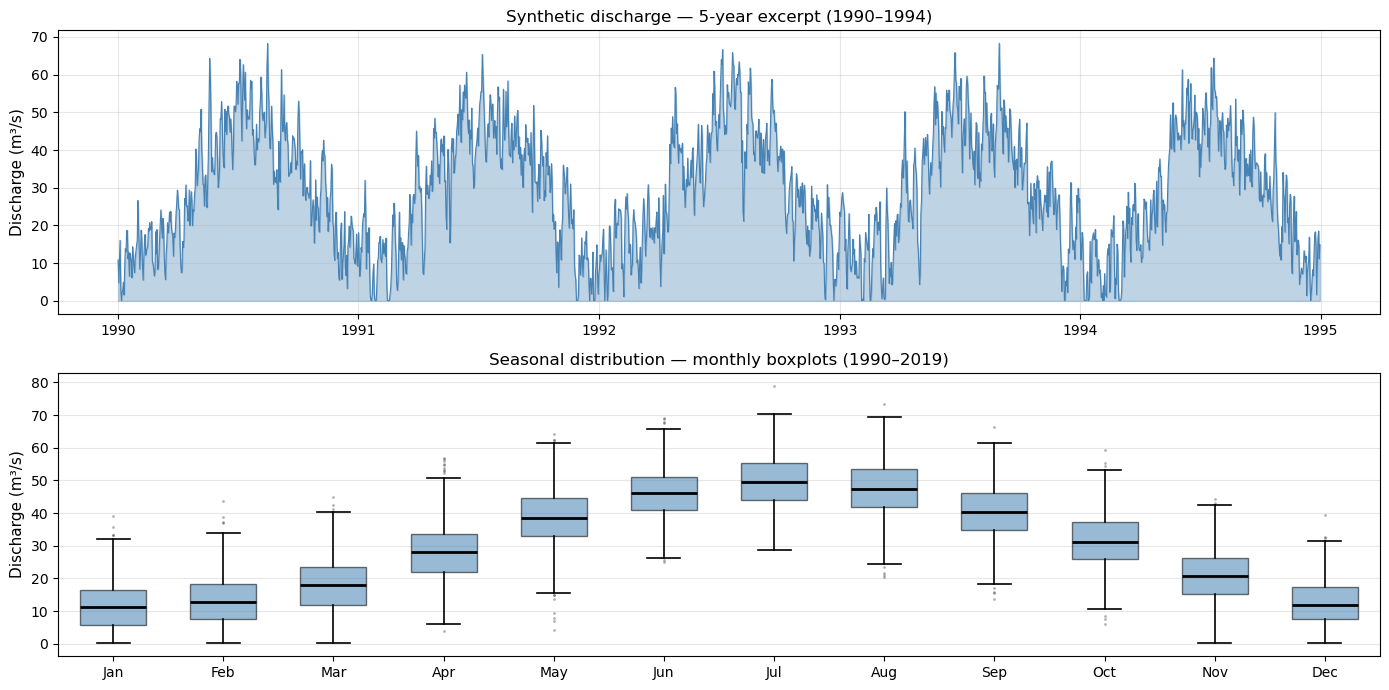

In [3]:
# Generate a synthetic 30-year daily discharge series with AR(1) persistence
rng   = np.random.default_rng(42)
dates = pd.date_range("1990-01-01", "2019-12-31", freq="D")
n     = len(dates)
doy   = np.asarray(dates.dayofyear, dtype=float)

# Seasonal mean: peaks in late summer
seasonal_mean = 30 + 20 * np.sin(2 * np.pi * (doy / 365 - 0.3))

# AR(1) noise with ρ=0.7 — realistic day-to-day persistence around the seasonal mean
rho = 0.7
eps = rng.normal(0, 8 * np.sqrt(1 - rho**2), n)
noise = np.zeros(n)
for t in range(1, n):
    noise[t] = rho * noise[t-1] + eps[t]

Q     = np.maximum(0.1, seasonal_mean + noise)
Q_obs = pd.Series(Q, index=dates, name="discharge")

# Detrended lag-1 ACF (remove seasonal mean before computing)
Q_detrend = Q_obs - Q_obs.groupby(Q_obs.index.dayofyear).transform('mean')
print(f"Period            : {dates[0].date()} → {dates[-1].date()}")
print(f"Mean Q            : {Q_obs.mean():.2f} m³/s")
print(f"Std  Q            : {Q_obs.std():.2f} m³/s")
print(f"Global lag-1 ACF  : {Q_obs.autocorr(lag=1):.3f}  (inflated by seasonality)")
print(f"Detrended lag-1   : {Q_detrend.autocorr(lag=1):.3f}  (AR(1) noise ρ ≈ 0.70)")

# ── Figure: 5-year excerpt (top) + monthly boxplots (bottom) ─────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

excerpt = Q_obs["1990":"1994"]
ax1.fill_between(excerpt.index, excerpt.values, alpha=0.35, color="steelblue")
ax1.plot(excerpt.index, excerpt.values, lw=0.8, color="steelblue")
ax1.set_ylabel("Discharge (m³/s)", fontsize=11)
ax1.set_title("Synthetic discharge — 5-year excerpt (1990–1994)", fontsize=12)
ax1.grid(alpha=0.3)

months_lbl = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
month_data = [Q_obs[Q_obs.index.month == m].values for m in range(1, 13)]
ax2.boxplot(month_data, patch_artist=True, widths=0.6,
            boxprops=dict(facecolor="steelblue", alpha=0.55),
            medianprops=dict(color="black", lw=2),
            whiskerprops=dict(lw=1.2), capprops=dict(lw=1.2),
            flierprops=dict(marker=".", markersize=2, alpha=0.3))
ax2.set_xticklabels(months_lbl, fontsize=10)
ax2.set_ylabel("Discharge (m³/s)", fontsize=11)
ax2.set_title("Seasonal distribution — monthly boxplots (1990–2019)", fontsize=12)
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

Distribution : gengamma
Parameters   : {'scale': np.float64(75.78079813649286), 'shape1': np.float64(0.6523093256425196), 'shape2': np.float64(56.132770775858276)}
Fit RMSE     : 0.1395



ACS fitted for 12 months
January  — model: weibull,  params: {'scale': np.float64(2.8481949975654546), 'shape': np.float64(1.2796048291433648)}
July     — model: weibull,  params: {'scale': np.float64(2.520964854490056), 'shape': np.float64(0.965504148353909)}


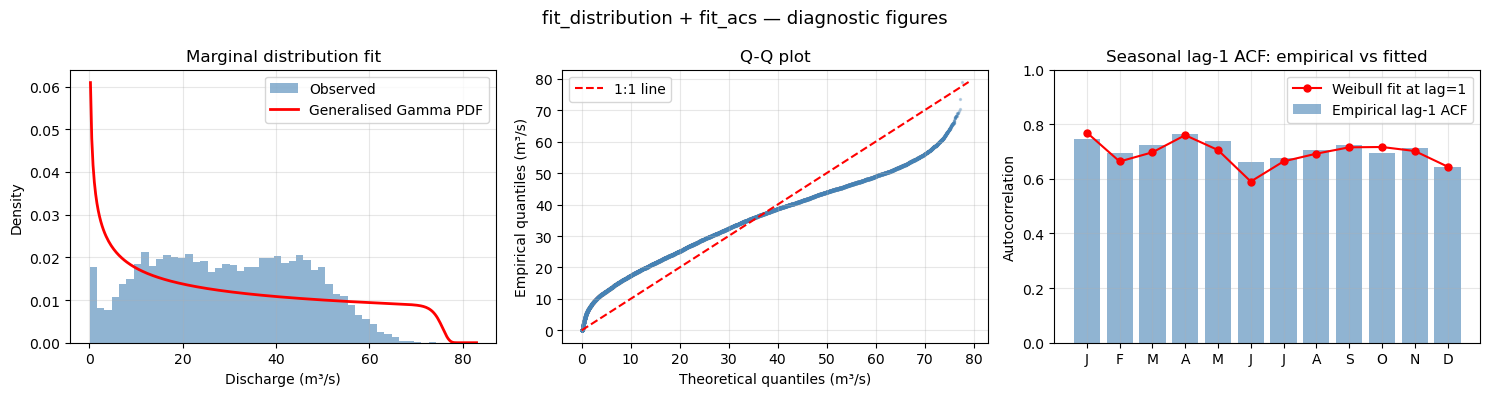

In [4]:
from scipy import stats as spstats

# ── Fit marginal distribution ─────────────────────────────────────────────────
dist = fit_distribution(Q_obs, dist='gengamma')
print(f"Distribution : {dist['dist']}")
print(f"Parameters   : {dist['params_dict']}")
print(f"Fit RMSE     : {dist['objective']:.4f}")

# ── Fit seasonal ACS (lag_max=8 avoids overfitting noise at long lags) ────────
acs = fit_acs(Q_obs, lag_max=8)
print(f"\nACS fitted for {len(acs)} months")
print(f"January  — model: {acs[0]['acs_id']},  params: {acs[0]['params']}")
print(f"July     — model: {acs[6]['acs_id']},  params: {acs[6]['params']}")

# ── 3-panel diagnostic figure ─────────────────────────────────────────────────
p   = dist['params_dict']
rv  = spstats.gengamma(a=p['shape1']/p['shape2'], c=p['shape2'], scale=p['scale'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1 — Histogram + fitted PDF
q_vals = Q_obs.values
x_pdf  = np.linspace(0, q_vals.max() * 1.05, 300)
axes[0].hist(q_vals, bins=50, density=True, color="steelblue", alpha=0.6, label="Observed")
axes[0].plot(x_pdf, rv.pdf(x_pdf), "r-", lw=2, label="Generalised Gamma PDF")
axes[0].set_xlabel("Discharge (m³/s)"); axes[0].set_ylabel("Density")
axes[0].set_title("Marginal distribution fit"); axes[0].legend(); axes[0].grid(alpha=0.3)

# Panel 2 — Q-Q plot
q_sorted = np.sort(q_vals)
probs    = (np.arange(1, len(q_sorted) + 1) - 0.5) / len(q_sorted)
q_theory = rv.ppf(probs)
axes[1].scatter(q_theory, q_sorted, s=2, alpha=0.3, color="steelblue")
lims = [min(q_theory.min(), q_sorted.min()), max(q_theory.max(), q_sorted.max())]
axes[1].plot(lims, lims, "r--", lw=1.5, label="1:1 line")
axes[1].set_xlabel("Theoretical quantiles (m³/s)"); axes[1].set_ylabel("Empirical quantiles (m³/s)")
axes[1].set_title("Q-Q plot"); axes[1].legend(); axes[1].grid(alpha=0.3)

# Panel 3 — Seasonal lag-1 ACF: empirical bars vs Weibull fit points
months_lbl = ["J","F","M","A","M","J","J","A","S","O","N","D"]
e_lag1 = [acs[m]['e_acs'][1] if len(acs[m]['e_acs']) > 1 else 0.0 for m in range(12)]
f_lag1 = [float(np.exp(-(1.0 / acs[m]['params']['scale']) ** acs[m]['params']['shape']))
          for m in range(12)]
axes[2].bar(range(12), e_lag1, color="steelblue", alpha=0.6, label="Empirical lag-1 ACF")
axes[2].plot(range(12), f_lag1, "ro-", ms=5, lw=1.5, label="Weibull fit at lag=1")
axes[2].set_xticks(range(12)); axes[2].set_xticklabels(months_lbl)
axes[2].set_ylabel("Autocorrelation"); axes[2].set_ylim(0, 1)
axes[2].set_title("Seasonal lag-1 ACF: empirical vs fitted"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("fit_distribution + fit_acs — diagnostic figures", fontsize=13)
plt.tight_layout()
plt.show()

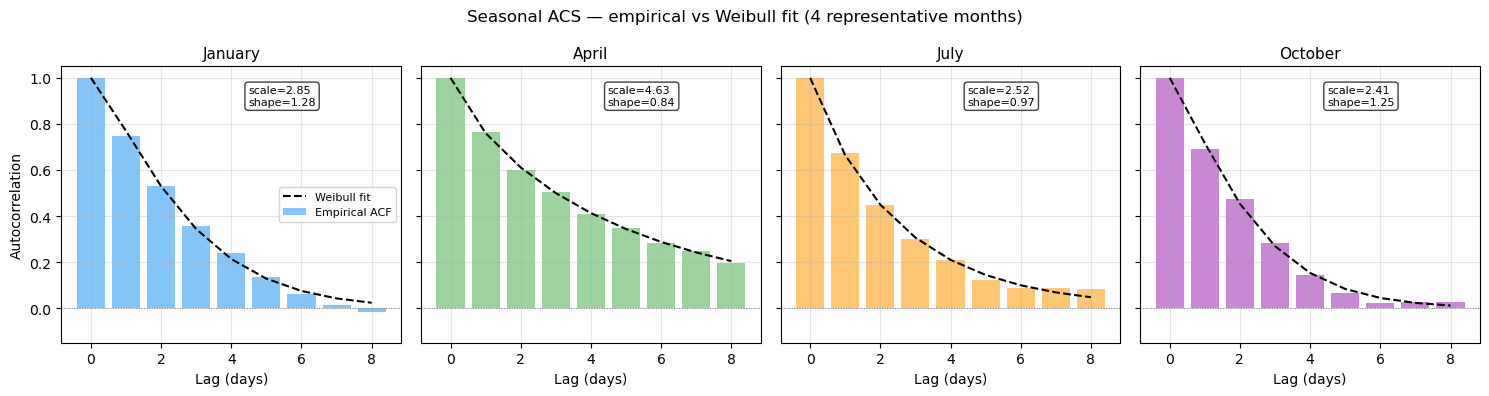

In [5]:
# Multi-lag ACF visualization: 4 representative months
months_to_plot = [0, 3, 6, 9]
month_names    = ["January", "April", "July", "October"]
colors         = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"]

fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

for ax, m, name, col in zip(axes, months_to_plot, month_names, colors):
    e_acs  = acs[m]['e_acs']
    params = acs[m]['params']
    lags   = np.arange(len(e_acs))
    f_acs  = np.exp(-(lags / params['scale']) ** params['shape'])

    ax.bar(lags, e_acs, color=col, alpha=0.55, label="Empirical ACF")
    ax.plot(lags, f_acs, "k--", lw=1.5, label="Weibull fit")
    ax.axhline(0, color="gray", lw=0.7, ls=":")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Lag (days)")
    ax.set_ylim(-0.15, 1.05)
    ax.grid(alpha=0.3)
    ax.text(0.55, 0.86,
            f"scale={params['scale']:.2f}\nshape={params['shape']:.2f}",
            transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.75))
    if ax is axes[0]:
        ax.set_ylabel("Autocorrelation")
        ax.legend(fontsize=8)

plt.suptitle("Seasonal ACS — empirical vs Weibull fit (4 representative months)", fontsize=12)
plt.tight_layout()
plt.show()

Fitting stochastic model (analyze_ts) ...


Done.

              dist       mean        sd   p0   acs.l.2
season                                                
month_1   gengamma  11.510128  7.574565  0.0  0.746066
month_2   gengamma  13.131670  7.647988  0.0  0.694925
month_3   gengamma  17.636273  8.429115  0.0  0.725561
month_4   gengamma  28.108478  9.009652  0.0  0.763572
month_5   gengamma  38.613403  8.805122  0.0  0.739609
month_6   gengamma  46.181519  7.688429  0.0  0.663221
month_7   gengamma  49.682245  7.754884  0.0  0.675789
month_8   gengamma  47.412456  8.500051  0.0  0.706350
month_9   gengamma  40.326035  8.305442  0.0  0.725681
month_10  gengamma  31.365845  8.123243  0.0  0.693103
month_11  gengamma  20.769181  8.058084  0.0  0.713542
month_12  gengamma  12.291320  7.038899  0.0  0.644120


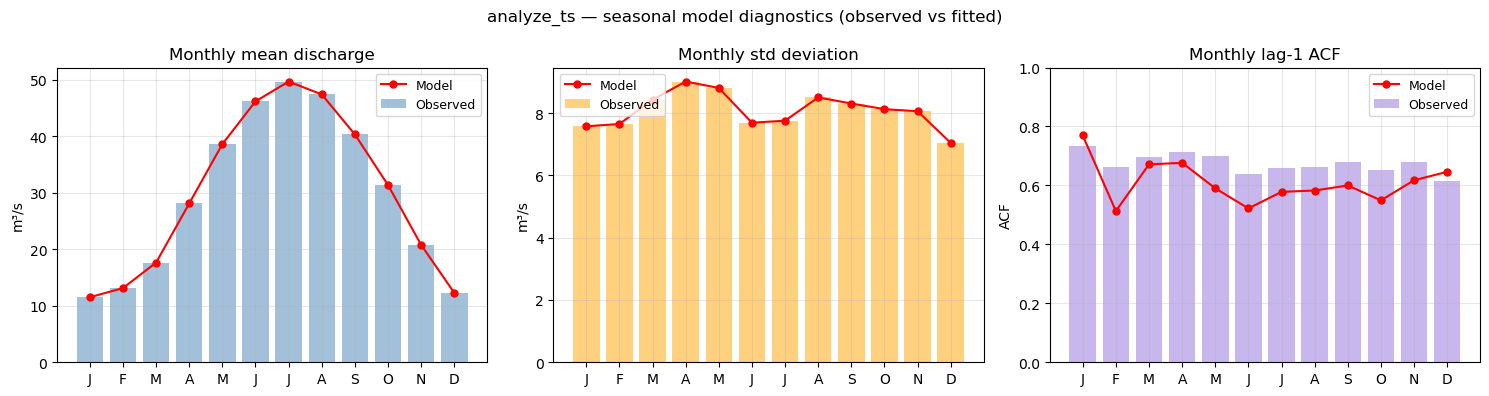

In [6]:
# Analyse the full series — fit seasonal marginals + ACS in one call
print("Fitting stochastic model (analyze_ts) ...")
ts_stats = analyze_ts(Q_obs, dist='gengamma', acs_id='weibull')
print("Done.\n")

stats_df = report_ts(ts_stats)
print(stats_df[['dist', 'mean', 'sd', 'p0', 'acs.l.2']].to_string())

# ── Seasonal diagnostics: observed vs model ───────────────────────────────────
months = list(range(1, 13))
lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]

obs_mean = np.array([Q_obs[Q_obs.index.month == m].mean() for m in months])
obs_std  = np.array([Q_obs[Q_obs.index.month == m].std()  for m in months])
obs_acf1 = np.array([Q_obs[Q_obs.index.month == m].autocorr(lag=1) for m in months])

mod_mean = stats_df['mean'].values
mod_std  = stats_df['sd'].values
# Lag-1 ACF from Weibull fit: r(1) = exp(-(1/scale)^shape)
mod_acf1 = np.array([
    float(np.exp(-(1.0 / ts_stats['afits'][m]['params']['scale'])
                 ** ts_stats['afits'][m]['params']['shape']))
    for m in range(12)
])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [
    (axes[0], obs_mean, mod_mean, "Monthly mean discharge", "m³/s",  "steelblue"),
    (axes[1], obs_std,  mod_std,  "Monthly std deviation",  "m³/s",  "orange"),
    (axes[2], obs_acf1, mod_acf1, "Monthly lag-1 ACF",      "ACF",   "mediumpurple"),
]
for ax, obs, mod, title, ylabel, col in pairs:
    ax.bar(months, obs, color=col, alpha=0.5, label="Observed")
    ax.plot(months, mod, "ro-", ms=5, lw=1.5, label="Model")
    ax.set_xticks(months); ax.set_xticklabels(lbl)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
axes[2].set_ylim(0, 1)

plt.suptitle("analyze_ts — seasonal model diagnostics (observed vs fitted)", fontsize=12)
plt.tight_layout()
plt.show()

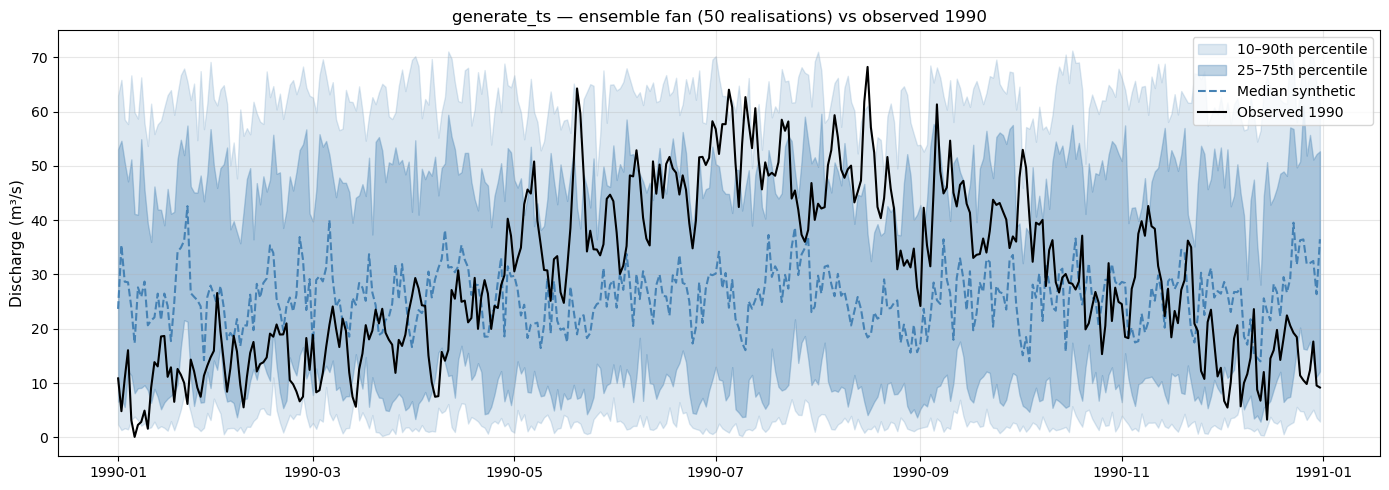

Observed  — mean: 29.83 m³/s,  std: 16.08 m³/s
Synthetic — mean: 29.51 m³/s,  std: 22.57 m³/s
Ensemble shape : (50, 365)  (n_sims × n_days)


In [7]:
# Generate ensemble of N synthetic realisations (annual model, no seasonality)
N_SIM = 50

dist_fit_full = fit_distribution(Q_obs, dist='gengamma')
acs_fit_full  = fit_acs(Q_obs, lag_max=8)

# Average empirical ACS across months
acs_vals = [1.0]
for lag in range(1, 6):
    lag_vals = [m['e_acs'][lag] for m in acs_fit_full if lag < len(m['e_acs'])]
    acs_vals.append(float(np.mean(lag_vals)) if lag_vals else 0.0)

sims = generate_ts(365, dist_fit_full['dist'], dist_fit_full['params_dict'],
                   acs_vals, p0=0.0, n_series=N_SIM)

sim_arr   = np.array([np.asarray(s) for s in sims])   # (N_SIM, 365)
sim_dates = pd.date_range("1990-01-01", periods=365, freq="D")
p10, p25, p50, p75, p90 = [np.percentile(sim_arr, p, axis=0) for p in [10, 25, 50, 75, 90]]

# ── Fan-envelope figure ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(sim_dates, p10, p90, alpha=0.18, color="steelblue", label="10–90th percentile")
ax.fill_between(sim_dates, p25, p75, alpha=0.35, color="steelblue", label="25–75th percentile")
ax.plot(sim_dates, p50, lw=1.5, color="steelblue", ls="--", label="Median synthetic")
ax.plot(Q_obs.loc["1990"].index, Q_obs.loc["1990"].values,
        lw=1.5, color="black", label="Observed 1990")

ax.set_ylabel("Discharge (m³/s)", fontsize=11)
ax.set_title(f"generate_ts — ensemble fan ({N_SIM} realisations) vs observed 1990", fontsize=12)
ax.legend(loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Observed  — mean: {Q_obs.mean():.2f} m³/s,  std: {Q_obs.std():.2f} m³/s")
print(f"Synthetic — mean: {sim_arr.mean():.2f} m³/s,  std: {sim_arr.std():.2f} m³/s")
print(f"Ensemble shape : {sim_arr.shape}  (n_sims × n_days)")

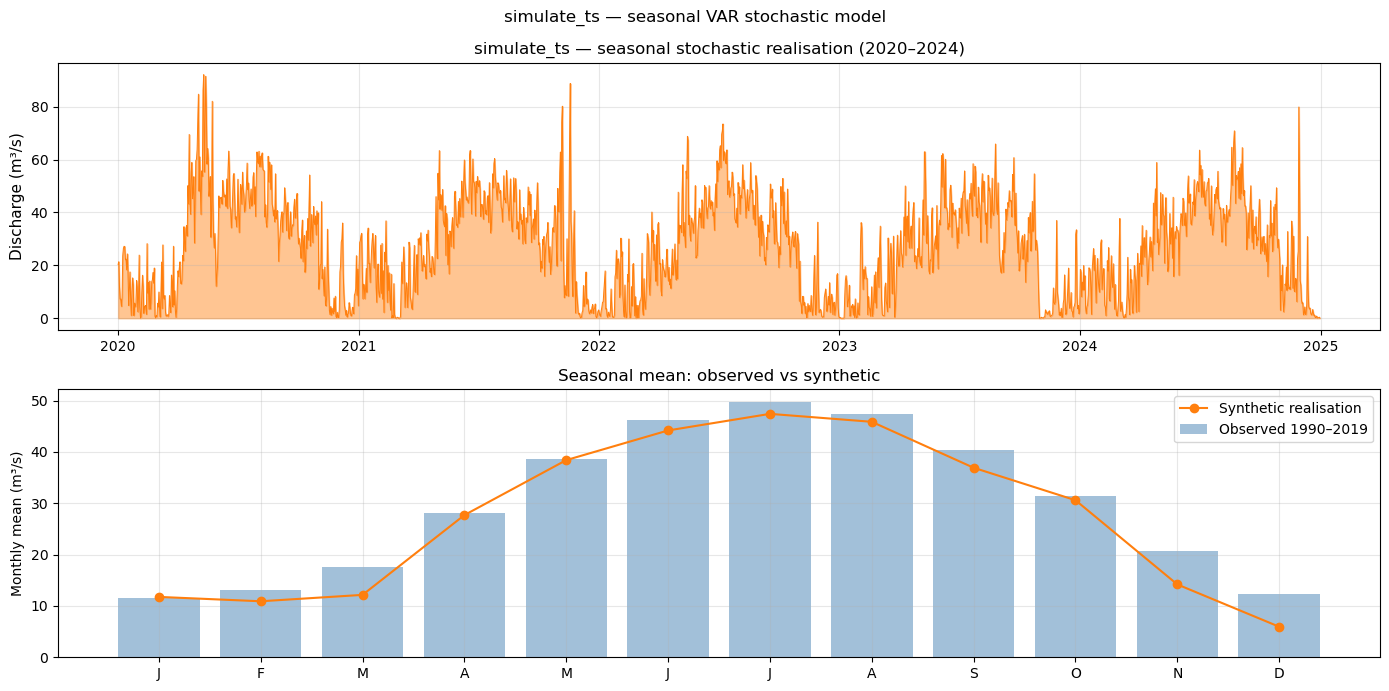

Realisation: 2020-01-01 → 2024-12-31  (1827 days)


In [8]:
# simulate_ts — single realisation from the seasonal stochastic model
# Unlike generate_ts (annual model), simulate_ts uses the seasonal VAR model
# fitted by analyze_ts, so it preserves monthly mean/variance patterns.
sim_ts = simulate_ts(ts_stats, from_date="2020-01-01", to_date="2024-12-31")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))

# Top: full 5-year realisation
ax1.fill_between(sim_ts['date'], sim_ts['value'], alpha=0.45, color="C1")
ax1.plot(sim_ts['date'], sim_ts['value'], lw=0.7, color="C1")
ax1.set_ylabel("Discharge (m³/s)", fontsize=11)
ax1.set_title("simulate_ts — seasonal stochastic realisation (2020–2024)", fontsize=12)
ax1.grid(alpha=0.3)

# Bottom: seasonal mean comparison
months = list(range(1, 13))
lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]
sim_df = sim_ts.set_index("date")
sim_monthly = [sim_df[sim_df.index.month == m]["value"].mean() for m in months]
obs_monthly = [Q_obs[Q_obs.index.month == m].mean() for m in months]

ax2.bar(months, obs_monthly, color="steelblue", alpha=0.5, label="Observed 1990–2019")
ax2.plot(months, sim_monthly, "o-", color="C1", ms=6, lw=1.5, label="Synthetic realisation")
ax2.set_xticks(months); ax2.set_xticklabels(lbl)
ax2.set_ylabel("Monthly mean (m³/s)"); ax2.set_title("Seasonal mean: observed vs synthetic")
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle("simulate_ts — seasonal VAR stochastic model", fontsize=12)
plt.tight_layout()
plt.show()
print(f"Realisation: {sim_ts['date'].iloc[0].date()} → {sim_ts['date'].iloc[-1].date()}  ({len(sim_ts)} days)")

---
## 2. Precipitation — NSRP Model (NEOPRENE)

The **Neyman-Scott Rectangular Pulses Model (NSRPM)** is a **process-based** stochastic model for precipitation. Unlike the empirical CoSMoS approach, it encodes a physical description of the rainfall generation process.

### Physical process

```
Storm arrivals  ~ Poisson(λ)
  └─ Each storm spawns cells ~ Poisson(μ_c)
       └─ Each cell has:
            ├─ Duration L  ~ Exponential(η)      [hours]
            ├─ Intensity X ~ Exponential(ξ)      [mm/h]
            └─ Lag Δt      ~ Exponential(β)  from storm origin
```

Rainfall at time $t$ = sum of intensities of all active cells overlapping $t$.

### Calibration via PSO

The NSRP model is calibrated by **Particle Swarm Optimisation (PSO)**, minimising a weighted distance between observed and modelled statistics for each month:

| Target statistic | Symbol | Hydrological relevance |
|-----------------|--------|------------------------|
| Mean | $\mu$ | Preserves total rainfall volume |
| Variance | $\sigma^2$ | Preserves inter-event variability |
| Lag-1 covariance | $\text{Cov}(1)$ | Preserves short-range persistence |
| Probability dry | $p_0$ | Preserves dry-day intermittency |

### Model variants

| Class | Model | Sites | Input |
|-------|-------|-------|-------|
| `NSRPModel` | NSRPM | Single-site | `pd.Series` |
| `STNSRPModel` | ST-NSRPM | Multi-site spatial | `pd.DataFrame` |

> **Requires NEOPRENE:** `pip install NEOPRENE`  
> Reference: Rodríguez-Iturbe et al. (1987); Cowpertwait (1994); IH Cantabria

In [9]:
# Generate a synthetic 30-year daily precipitation series using a Markov chain.
#
# Why Markov chain instead of independent Bernoulli draws?
# NSRP (Neyman-Scott) models precipitation as clustered storms: each storm
# spawns a Poisson number of cells, each with exponential duration and intensity.
# The resulting sequence has multi-day wet spells separated by dry gaps — a
# 2-state Markov structure. Independent Bernoulli draws have no wet-spell
# memory, so PSO cannot recover fih_1 and produces near-100% wet output.
rng_p   = np.random.default_rng(42)
dates_p = pd.date_range("1990-01-01", "2019-12-31", freq="D")
n_p     = len(dates_p)
doy_p   = np.asarray(dates_p.dayofyear, dtype=float)

# Seasonal storm-arrival probability (dry→wet): peaks in spring
p_d2w = 0.22 + 0.06 * np.sin(2 * np.pi * (doy_p / 365 - 0.1))
p_w2d = 0.50  # persistence 0.50 → mean storm duration ≈ 2 days

state = 0
wet   = np.zeros(n_p, dtype=bool)
for t in range(n_p):
    if state == 0 and rng_p.random() < p_d2w[t]:
        state = 1
    elif state == 1 and rng_p.random() < p_w2d:
        state = 0
    wet[t] = bool(state)

prec  = np.where(wet, rng_p.exponential(8, n_p), 0.0)
P_obs = pd.Series(prec, index=dates_p, name="precipitation")

print(f"Wet-day fraction : {(P_obs > 0).mean():.2f}")
print(f"Mean             : {P_obs.mean():.2f} mm/day")
print(f"Std              : {P_obs.std():.2f} mm/day")
print(f"Max              : {P_obs.max():.1f} mm")

Wet-day fraction : 0.30
Mean             : 2.48 mm/day
Std              : 5.87 mm/day
Max              : 62.2 mm


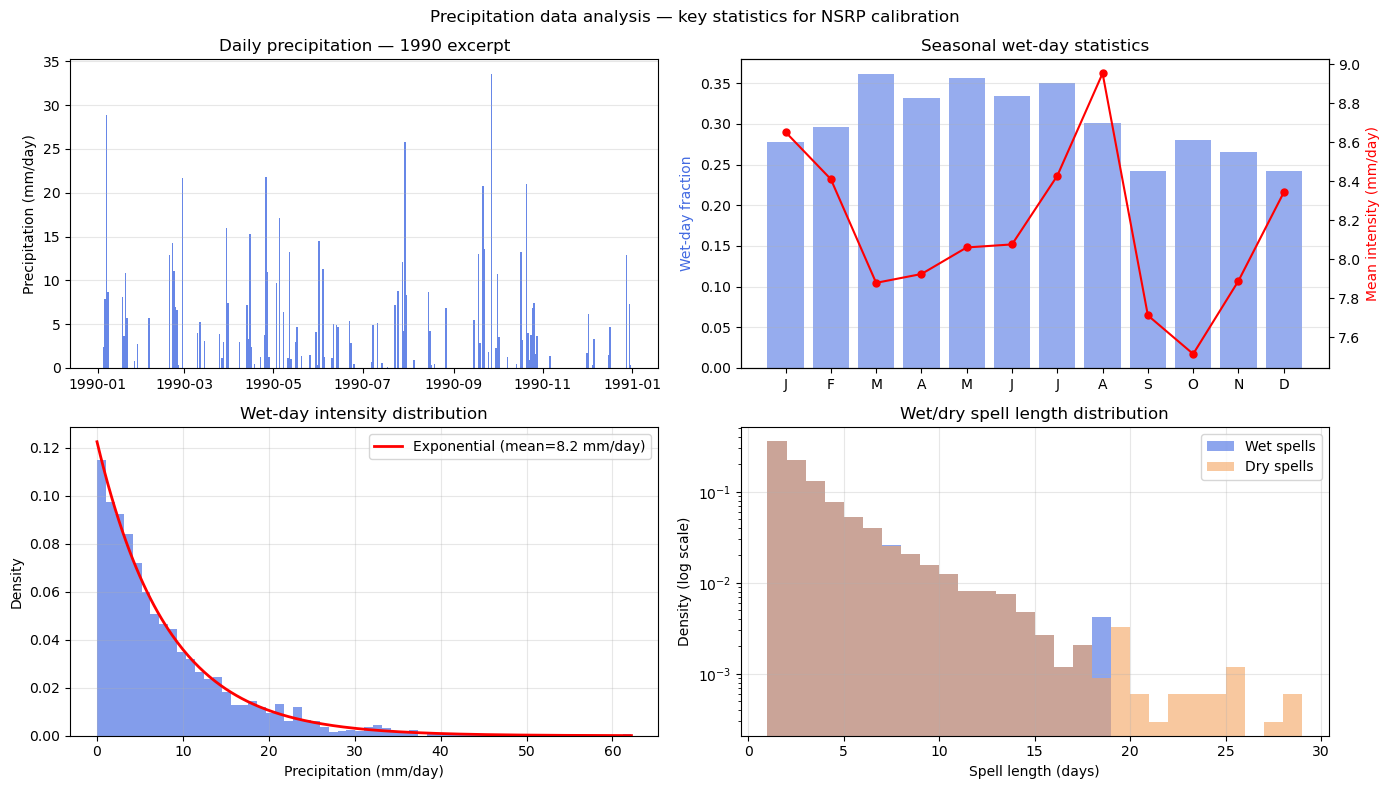

Wet-day fraction : 0.30
Mean intensity   : 8.16 mm/day
Mean wet spell   : 3.3 days
Mean dry spell   : 3.3 days


In [10]:
# Exploratory analysis of the precipitation series — 4-panel figure
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Panel 1: Daily time series (1-year excerpt)
excerpt_p = P_obs["1990"]
axes[0, 0].bar(excerpt_p.index, excerpt_p.values, width=1, color="royalblue", alpha=0.8)
axes[0, 0].set_ylabel("Precipitation (mm/day)")
axes[0, 0].set_title("Daily precipitation — 1990 excerpt")
axes[0, 0].grid(alpha=0.3, axis="y")

# Panel 2: Monthly wet-day fraction + mean wet-day intensity
months_p   = list(range(1, 13))
lbl_p      = ["J","F","M","A","M","J","J","A","S","O","N","D"]
wet_frac   = [(P_obs[P_obs.index.month == m] > 0).mean() for m in months_p]
mean_int   = [P_obs[(P_obs.index.month == m) & (P_obs > 0)].mean() for m in months_p]

ax2a = axes[0, 1]
ax2b = ax2a.twinx()
ax2a.bar(months_p, wet_frac, color="royalblue", alpha=0.55, label="Wet-day fraction")
ax2b.plot(months_p, mean_int, "ro-", ms=5, lw=1.5, label="Mean wet-day intensity")
ax2a.set_xticks(months_p); ax2a.set_xticklabels(lbl_p)
ax2a.set_ylabel("Wet-day fraction", color="royalblue")
ax2b.set_ylabel("Mean intensity (mm/day)", color="red")
ax2a.set_title("Seasonal wet-day statistics")
ax2a.grid(alpha=0.3, axis="y")

# Panel 3: Wet-day intensity distribution
wet_vals  = P_obs[P_obs > 0].values
loc_e, sc_e = spstats.expon.fit(wet_vals, floc=0)
x_exp     = np.linspace(0, wet_vals.max(), 300)
axes[1, 0].hist(wet_vals, bins=60, color="royalblue", alpha=0.65, density=True)
axes[1, 0].plot(x_exp, spstats.expon.pdf(x_exp, scale=sc_e), "r-", lw=2,
                label=f"Exponential (mean={sc_e:.1f} mm/day)")
axes[1, 0].set_xlabel("Precipitation (mm/day)"); axes[1, 0].set_ylabel("Density")
axes[1, 0].set_title("Wet-day intensity distribution"); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# Panel 4: Wet/dry spell length distribution
def _spell_lengths(series, wet):
    out, count = [], 0
    in_spell = (series.iloc[0] > 0) == wet
    for v in series.values:
        same = (v > 0) == wet
        if same == in_spell:
            count += 1
        else:
            if count > 0:
                out.append(count)
            in_spell, count = same, 1
    if count > 0:
        out.append(count)
    return np.array(out)

wet_spells = _spell_lengths(P_obs, True)
dry_spells = _spell_lengths(P_obs, False)
axes[1, 1].hist(wet_spells, bins=range(1, 20), color="royalblue", alpha=0.6, density=True, label="Wet spells")
axes[1, 1].hist(dry_spells, bins=range(1, 30), color="sandybrown", alpha=0.6, density=True, label="Dry spells")
axes[1, 1].set_xlabel("Spell length (days)"); axes[1, 1].set_ylabel("Density (log scale)")
axes[1, 1].set_yscale("log"); axes[1, 1].set_title("Wet/dry spell length distribution")
axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.suptitle("Precipitation data analysis — key statistics for NSRP calibration", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Wet-day fraction : {(P_obs > 0).mean():.2f}")
print(f"Mean intensity   : {P_obs[P_obs > 0].mean():.2f} mm/day")
print(f"Mean wet spell   : {wet_spells.mean():.1f} days")
print(f"Mean dry spell   : {dry_spells.mean():.1f} days")

In [11]:
try:
    # NSRPModel uses default statistics: mean, var_1, autocorr_1_1, fih_1
    # These are the NEOPRENE-format names (NEOPRENE requires lag/aggregation suffix)
    model = NSRPModel(
        temporal_resolution='d',
        seasonality='monthly',
        n_iterations=100,
        n_bees=20,
    )
    print(model)
    print(f"Statistics : {model.statistics_name}")
    print(f"Weights    : {model.weights}")
except Exception as e:
    print(f"NSRPModel error: {e}")

Statistics : ['mean', 'var_1', 'autocorr_1_1', 'fih_1']
Weights    : [1.0, 1.0, 1.0, 1.0]


Observed statistics — NSRP calibration targets:
                      1         2          3          4          5          6          7          8          9        10         11         12
mean           2.400297  2.492489   2.846924   2.632885   2.877761   2.701203   2.954475    2.69552   1.868263  2.109192   2.095229   2.018474
var_1         36.665584  35.31536  36.332535  32.408431  36.624964  34.914324  44.510634  42.750202  24.560587  26.04454  28.051857  33.231806
autocorr_1_1   0.072627  0.131683   0.173187   0.092902   0.119402   0.019283    0.08737   0.094391   0.069749   0.09517   0.066483   0.124396
fih_1          0.722581  0.707202   0.641935   0.674444   0.647312   0.667778   0.654839   0.704301       0.76  0.721505   0.737778   0.762366


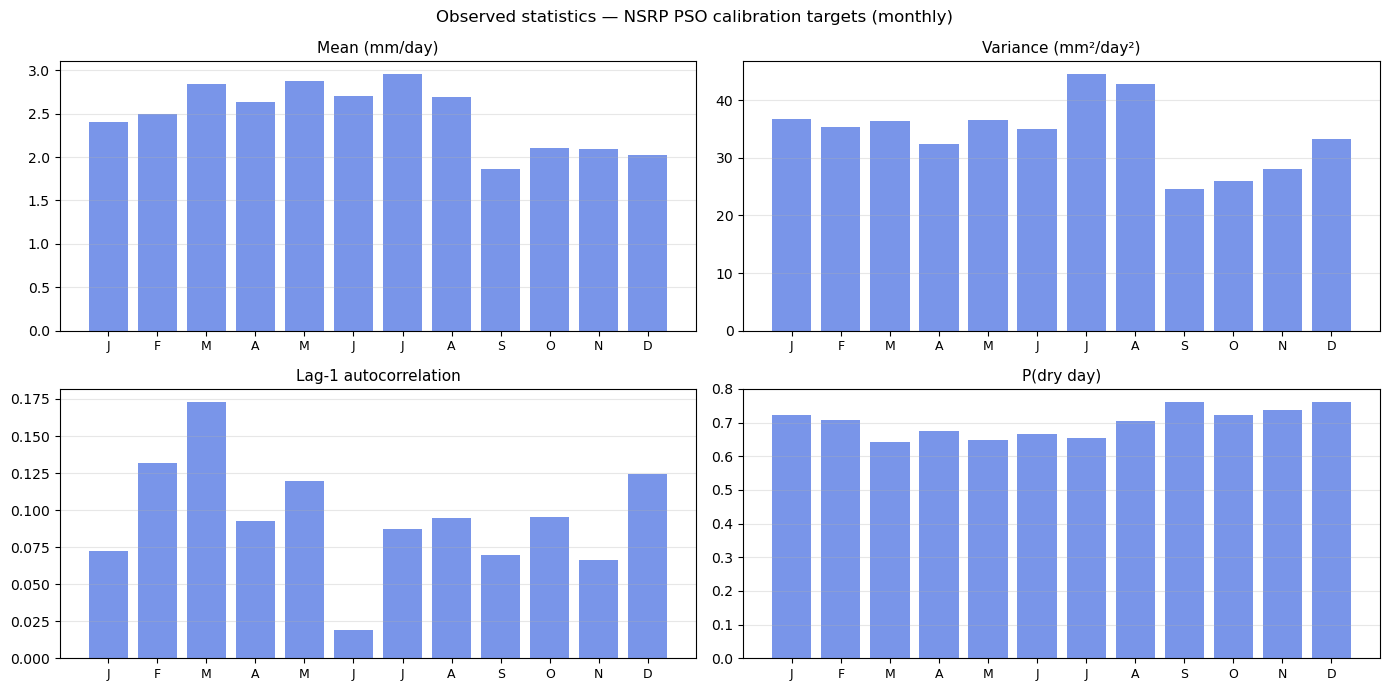

In [12]:
import warnings

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        obs_stats = model.compute_statistics(P_obs)

    df_obs = obs_stats.statististics_dataframe
    months = list(range(1, 13))
    lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]
    stat_labels = {
        "mean":         "Mean (mm/day)",
        "var_1":        "Variance (mm²/day²)",
        "autocorr_1_1": "Lag-1 autocorrelation",
        "fih_1":        "P(dry day)",
    }

    print("Observed statistics — NSRP calibration targets:")
    print(df_obs.round(3).to_string())

    # ── 4-panel: observed statistics per month (= PSO calibration targets) ────
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    for ax, (stat, label) in zip(axes.flat, stat_labels.items()):
        vals = df_obs.loc[stat].values.astype(float)
        ax.bar(months, vals, color="royalblue", alpha=0.7)
        ax.set_xticks(months); ax.set_xticklabels(lbl, fontsize=9)
        ax.set_title(label, fontsize=11); ax.grid(alpha=0.3, axis="y")

    plt.suptitle("Observed statistics — NSRP PSO calibration targets (monthly)", fontsize=12)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"compute_statistics not available: {e}")



################################################################################
Adjustment of parameters using the Particle Swarm Optimization (PSO)




Calibration done.

Fitted NSRP parameters (per month):
                1          2          3         4          5          6         7         8         9        10        11         12
landa    0.547135   0.249212   0.189133  0.411743    0.33904   1.350367  0.513315  0.428977  1.078659  0.491996  0.374953     0.1234
ipsilon  1.598669   5.846799  11.535269  2.219695   7.457321   1.000001  1.924899  2.110466  1.025606  2.144007  1.010364  10.512049
eta      7.726871  10.085404  17.522927  7.883376  16.638957  13.084496  7.280758  7.127304  9.765613  9.646633  5.045899  13.666696
xi          0.048      0.048      0.048     0.048      0.048      0.048     0.048     0.048     0.048     0.048     0.048      0.048
betha         2.4   2.198825   1.667675  2.269667        2.4        2.4       2.4       2.4  0.626569  2.386611  0.576161        2.4


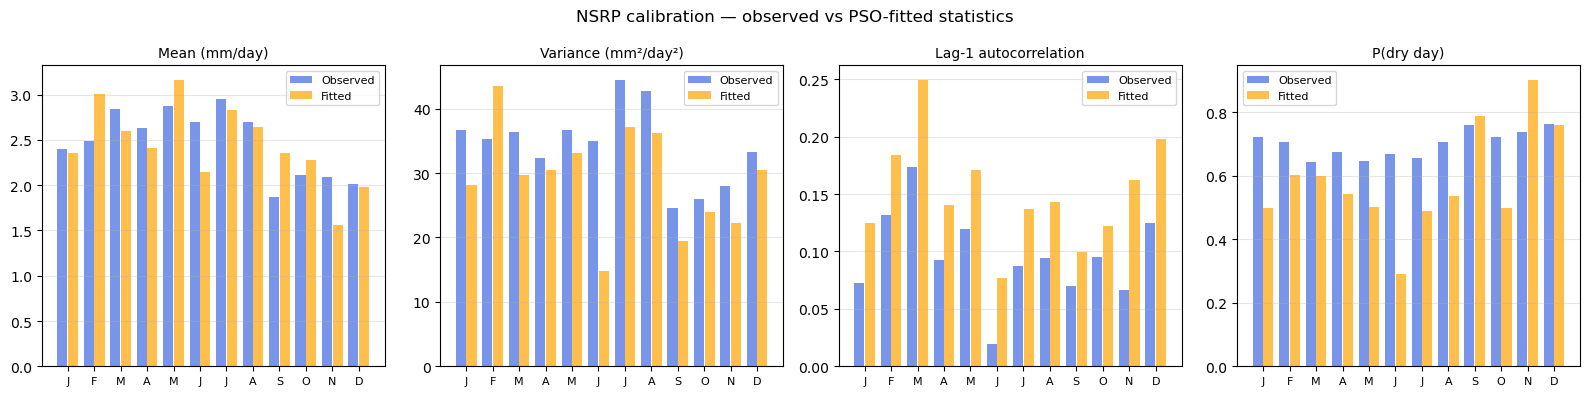

In [13]:
import warnings

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = model.calibrate(P_obs, verbose=False)

    print("Calibration done.\n")
    print("Fitted NSRP parameters (per month):")
    print(result.Fitted_parameters.round(4).to_string())

    # ── Observed vs fitted statistics per month ───────────────────────────────
    df_real = result.statististics_Real   # DataFrame: rows=stats, cols=months
    df_fit  = result.statististics_Fit    # DataFrame: rows=stats, cols=months
    months  = list(range(1, len(df_fit.columns) + 1))
    lbl     = ["J","F","M","A","M","J","J","A","S","O","N","D"][:len(months)]
    stat_labels = {
        "mean":         "Mean (mm/day)",
        "var_1":        "Variance (mm²/day²)",
        "autocorr_1_1": "Lag-1 autocorrelation",
        "fih_1":        "P(dry day)",
    }

    n   = len(df_fit.index)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    x = np.arange(len(months))

    for ax, stat in zip(axes, df_fit.index):
        obs_v = df_real.loc[stat].values.astype(float)
        fit_v = df_fit.loc[stat].values.astype(float)
        ax.bar(x - 0.2, obs_v, 0.38, color="royalblue", alpha=0.7, label="Observed")
        ax.bar(x + 0.2, fit_v, 0.38, color="orange",    alpha=0.7, label="Fitted")
        ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=8)
        ax.set_title(stat_labels.get(stat, stat), fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")

    plt.suptitle("NSRP calibration — observed vs PSO-fitted statistics", fontsize=12)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Calibration not available: {e}")
    print("  Install NEOPRENE:  pip install NEOPRENE")



################################################################################
Synthetic simulation




Total cumulative rainfall - Analytical estimation =        87144.13
Total cumulative rainfall -             Simulated =        87089.84


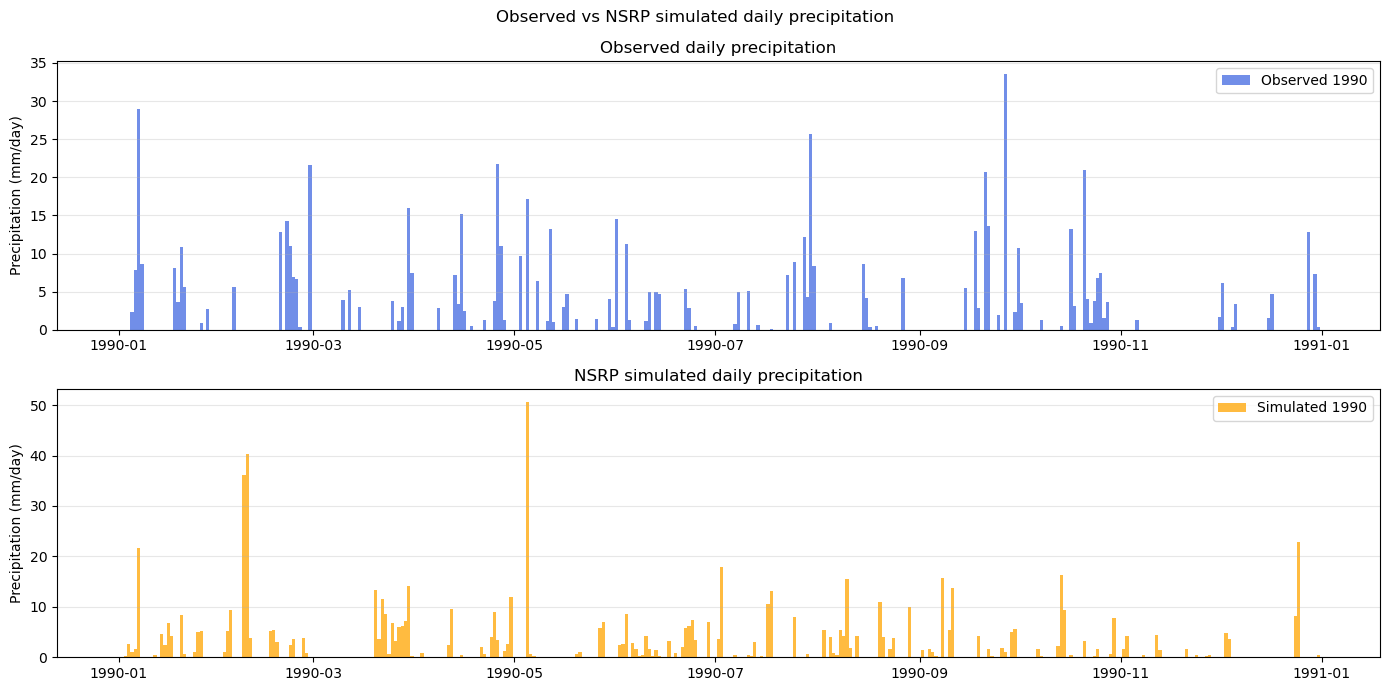

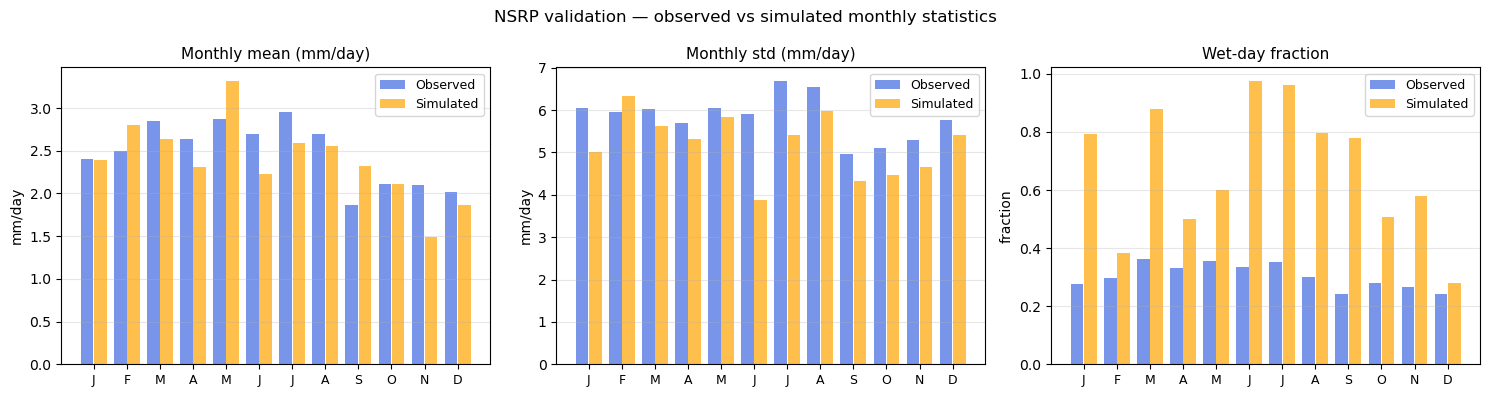

Simulated : 1990-01-01 → 2090-01-01  (36526 days)
Mean  — observed: 2.48 mm/day   simulated: 2.38 mm/day
Wet % — observed: 0.30        simulated: 0.67


In [14]:
import warnings

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sim_result = model.simulate(year_ini=1990, year_fin=2090)

    df_daily = sim_result.Daily_Simulation.copy()
    if hasattr(df_daily.index, 'to_timestamp'):
        df_daily.index = df_daily.index.to_timestamp()
    else:
        df_daily.index = pd.to_datetime(df_daily.index)

    rain_col = df_daily.columns[0]
    sim_s    = df_daily[rain_col]

    # ── Figure 1: time series — observed 1990 vs simulated first year ─────────
    obs_1yr  = P_obs.loc[P_obs.index.year == 1990]
    sim_1yr  = sim_s.loc[sim_s.index.year == sim_s.index.year[0]]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    axes[0].bar(obs_1yr.index, obs_1yr.values, width=1, color="royalblue", alpha=0.75, label="Observed 1990")
    axes[0].set_ylabel("Precipitation (mm/day)"); axes[0].set_title("Observed daily precipitation")
    axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")

    axes[1].bar(sim_1yr.index, sim_1yr.values, width=1, color="orange", alpha=0.75,
                label=f"Simulated {sim_1yr.index.year[0]}")
    axes[1].set_ylabel("Precipitation (mm/day)"); axes[1].set_title("NSRP simulated daily precipitation")
    axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

    plt.suptitle("Observed vs NSRP simulated daily precipitation", fontsize=12)
    plt.tight_layout()
    plt.show()

    # ── Figure 2: monthly statistics — observed vs simulated ──────────────────
    months = list(range(1, 13))
    lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]
    x      = np.arange(12)

    obs_mean = [P_obs[P_obs.index.month == m].mean() for m in months]
    obs_std  = [P_obs[P_obs.index.month == m].std()  for m in months]
    obs_wet  = [(P_obs[P_obs.index.month == m] > 0).mean() for m in months]
    sim_mean = [sim_s[sim_s.index.month == m].mean() for m in months]
    sim_std  = [sim_s[sim_s.index.month == m].std()  for m in months]
    sim_wet  = [(sim_s[sim_s.index.month == m] > 0).mean() for m in months]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, obs, sim, title, ylabel in zip(
        axes,
        [obs_mean, obs_std, obs_wet],
        [sim_mean, sim_std, sim_wet],
        ["Monthly mean (mm/day)", "Monthly std (mm/day)", "Wet-day fraction"],
        ["mm/day", "mm/day", "fraction"],
    ):
        ax.bar(x - 0.2, obs, 0.38, color="royalblue", alpha=0.7, label="Observed")
        ax.bar(x + 0.2, sim, 0.38, color="orange",    alpha=0.7, label="Simulated")
        ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=9)
        ax.set_title(title, fontsize=11); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")

    plt.suptitle("NSRP validation — observed vs simulated monthly statistics", fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f"Simulated : {sim_s.index[0].date()} → {sim_s.index[-1].date()}  ({len(sim_s)} days)")
    print(f"Mean  — observed: {P_obs.mean():.2f} mm/day   simulated: {sim_s.mean():.2f} mm/day")
    print(f"Wet % — observed: {(P_obs>0).mean():.2f}        simulated: {(sim_s>0).mean():.2f}")

except Exception as e:
    print(f"Simulation not available: {e}")
    print("  Run calibration first.")

---
## 3. Multi-site precipitation — ST-NSRP Model

The **Spatial-Temporal NSRPM (ST-NSRPM)** extends the single-site model to simultaneously reproduce precipitation at multiple rain gauges, including their **spatial cross-correlations**.

### When to use NSRP vs ST-NSRP

| Criterion | `NSRPModel` | `STNSRPModel` |
|-----------|------------|--------------|
| Number of sites | 1 | 2 or more |
| Spatial correlation | Not modelled | Reproduced |
| Use case | Catchment-integrated rainfall | Spatially distributed model forcing |
| Input | `pd.Series` | `pd.DataFrame` (dates × stations) |
| Calibration time | Low | Higher (cross-covariance per month) |

### API

```python
# Multi-site input: columns = rain gauge stations, index = dates
df_multisite = pd.DataFrame({
    "station_A": prec_A,
    "station_B": prec_B,
}, index=dates)

st_model = STNSRPModel(temporal_resolution='d', seasonality='monthly')
st_model.fit(df_multisite)          # PSO calibration per month
sim_result = st_model.simulate(year_ini=1990, year_fin=2090)
df_daily = sim_result.Daily_Simulation   # DataFrame: columns = stations
```

> **Spatial cross-correlation** is reproduced by fitting the inter-site covariance structure during PSO calibration — the model ensures that storms generate correlated wet/dry sequences across all stations simultaneously.

Station A — mean: 2.48 mm/day,  wet%: 0.30
Station B — mean: 2.40 mm/day,  wet%: 0.30
Annual cross-correlation A–B: 0.235


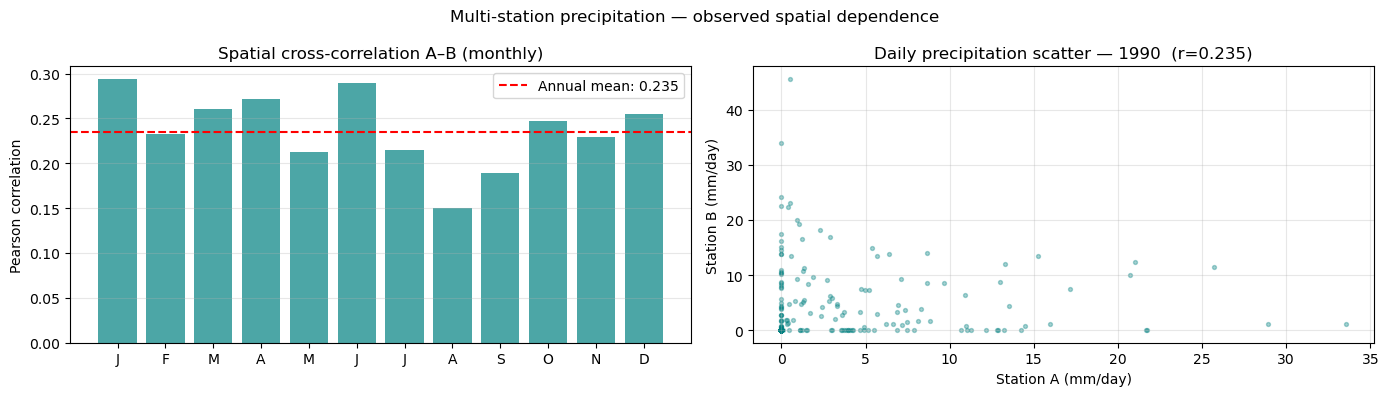



################################################################################
Adjustment of parameters using the Particle Swarm Optimization (PSO)





ST-NSRP calibration done.

Fitted parameters (per month):
              1        2        3        4        5        6        7        8        9        10       11       12
landa     0.3595   0.2997   0.3433   0.4191   0.4887   0.6639   0.4522   0.5305   0.5137   0.4360   0.4893   0.3390
ipsilon   1.8743   2.1801   2.4210   1.8464   1.5106   1.0000   1.5593   1.2679   1.0000   1.4866   1.1066   1.6292
eta      48.0000  48.0000  48.0000  48.0000  48.0000  48.0000  28.3198  44.2222  48.0000  48.0000  48.0000  48.0000
betha     2.4000   1.2156   1.3738   2.4000   1.7337   2.4000   2.4000   0.9839   2.4000   2.4000   2.4000   2.4000
fi_may    1.0000   1.0000   1.0000   1.0000   1.0000   0.4590   1.0000   1.0000   1.0000   1.0000   1.0000   1.0000


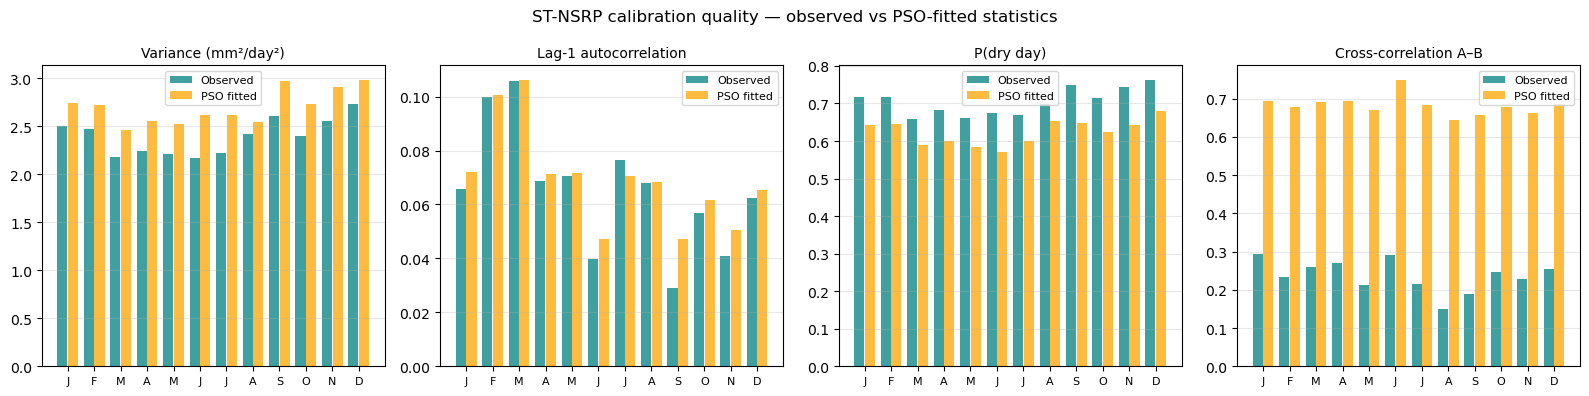



################################################################################
Synthetic simulation




Simulation corners: 
 xp:[np.float64(-3.8352417265644556), np.float64(-3.6647582734355444), np.float64(-3.6647582734355444), np.float64(-3.8352417265644556)]
 yp:[np.float64(43.26475827343554), np.float64(43.26475827343554), np.float64(43.435241726564456), np.float64(43.435241726564456)]
Simulation area (km²):261.6874557402037
Cells per storm per km²: 
[0.29830849 0.34696952 0.38530987 0.29386147 0.24042355 0.03353805
 0.24817025 0.20179792 0.15915494 0.23660564 0.17612725 0.25929588]
Cells per storm in my simulation area: 
[ 78.06358895  90.79756997 100.83075999  76.89985921  62.91582771
   8.77648723  64.94304089  52.80798303  41.64885243  61.916727
  46.09029094  67.85447874]
Number of storms 239 for the months 1
Number of rain cells per storm 77.8744769874477


  0%|          | 0/239 [00:00<?, ?it/s]

  7%|▋         | 16/239 [00:00<00:01, 150.01it/s]

 13%|█▎        | 32/239 [00:00<00:01, 144.79it/s]

...

 73%|███████▎  | 165/227 [00:01<00:00, 159.14it/s]

 80%|███████▉  | 181/227 [00:01<00:00, 159.36it/s]

 87%|████████▋ | 198/227 [00:01<00:00, 160.36it/s]

 95%|█████████▍| 215/227 [00:01<00:00, 161.91it/s]

100%|██████████| 227/227 [00:01<00:00, 160.23it/s]

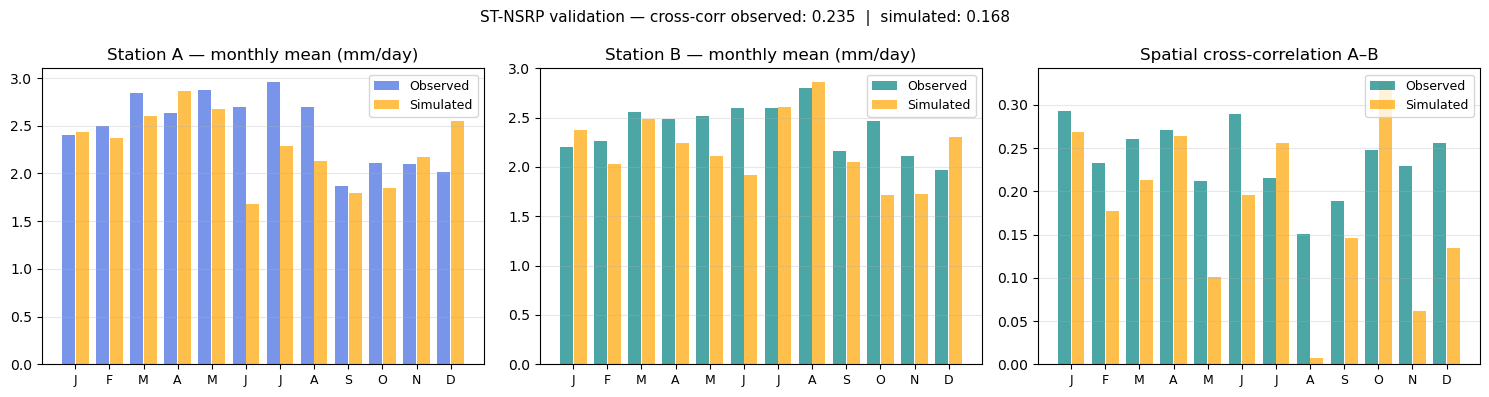


Cross-correlation — observed: 0.235   simulated: 0.168


In [15]:
import warnings

# ── 1. Generate 2 spatially-correlated precipitation stations ─────────────────
rng_st  = np.random.default_rng(99)
wet_A   = P_obs.values > 0

shared  = rng_st.random(len(P_obs)) < 0.70
wet_B   = (wet_A & shared) | ((~wet_A) & (rng_st.random(len(P_obs)) < 0.12))
prec_B  = np.where(wet_B, rng_st.exponential(8, len(P_obs)), 0.0)

P_B   = pd.Series(prec_B, index=P_obs.index, name="B")
df_st = pd.DataFrame({"A": P_obs.values, "B": prec_B}, index=P_obs.index)

attrs = pd.DataFrame({
    "ID":        ["A",    "B"],
    "Lon":       [-3.70,  -3.80],
    "Lat":       [43.30,  43.40],
    "elevation": [10.0,   50.0],
})

months = list(range(1, 13))
lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]

obs_xcorr = df_st["A"].corr(df_st["B"])
print(f"Station A — mean: {P_obs.mean():.2f} mm/day,  wet%: {(P_obs>0).mean():.2f}")
print(f"Station B — mean: {P_B.mean():.2f} mm/day,  wet%: {(P_B>0).mean():.2f}")
print(f"Annual cross-correlation A–B: {obs_xcorr:.3f}")

# ── 2. Seasonal cross-correlation + scatter ───────────────────────────────────
xcorr_m = [df_st[df_st.index.month == m]["A"].corr(df_st[df_st.index.month == m]["B"])
           for m in months]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.bar(months, xcorr_m, color="teal", alpha=0.7)
ax1.axhline(obs_xcorr, color="red", ls="--", lw=1.5, label=f"Annual mean: {obs_xcorr:.3f}")
ax1.set_xticks(months); ax1.set_xticklabels(lbl)
ax1.set_ylabel("Pearson correlation"); ax1.set_title("Spatial cross-correlation A–B (monthly)")
ax1.legend(); ax1.grid(alpha=0.3, axis="y")

yr = "1990"
ax2.scatter(df_st.loc[yr, "A"], df_st.loc[yr, "B"], alpha=0.35, s=8, color="teal")
ax2.set_xlabel("Station A (mm/day)"); ax2.set_ylabel("Station B (mm/day)")
ax2.set_title(f"Daily precipitation scatter — {yr}  (r={obs_xcorr:.3f})")
ax2.grid(alpha=0.3)
plt.suptitle("Multi-station precipitation — observed spatial dependence", fontsize=12)
plt.tight_layout(); plt.show()

# ── 3. Calibrate STNSRPModel ──────────────────────────────────────────────────
# STNSRP forbids 'mean'; requires 'crosscorr_h'.
# n_iterations=100, n_bees=20 → 2000 PSO evaluations per month (library defaults).
try:
    st_model = STNSRPModel(
        temporal_resolution='d',
        seasonality='monthly',
        statistics=['var_1', 'autocorr_1_1', 'fih_1', 'crosscorr_1'],
        n_iterations=100,
        n_bees=20,
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result_st = st_model.fit(df_st, attributes=attrs, verbose=False)

    print("\nST-NSRP calibration done.")
    print("\nFitted parameters (per month):")
    print(result_st.Fitted_parameters.round(4).to_string())

    # ── 4. Calibration quality: observed vs PSO-fitted statistics ─────────────
    # statististics_Real: {month_int: DataFrame(rows=stats, cols=stations)}
    # statististics_Fit:  {month_str: DataFrame(rows=stats, cols=stations)}
    # crosscorr_Real/Fit: {'crosscorr_1': {month_int: DataFrame(dist, cross_corr)}}
    point_stats = ['var_1', 'autocorr_1_1', 'fih_1']
    stat_labels = {
        'var_1':        'Variance (mm²/day²)',
        'autocorr_1_1': 'Lag-1 autocorrelation',
        'fih_1':        'P(dry day)',
        'crosscorr_1':  'Cross-correlation A–B',
    }

    # Average across stations for point statistics; use mean cross-corr for spatial
    def _monthly_stat(result, stat, key_type='int'):
        vals = []
        for m in range(1, 13):
            key = m if key_type == 'int' else str(m)
            df  = result[key]
            vals.append(float(df.loc[stat].mean()))  # average over stations
        return np.array(vals)

    obs_var  = _monthly_stat(result_st.statististics_Real, 'var_1',        'int')
    obs_acf  = _monthly_stat(result_st.statististics_Real, 'autocorr_1_1', 'int')
    obs_fih  = _monthly_stat(result_st.statististics_Real, 'fih_1',        'int')
    fit_var  = _monthly_stat(result_st.statististics_Fit,  'var_1',        'str')
    fit_acf  = _monthly_stat(result_st.statististics_Fit,  'autocorr_1_1', 'str')
    fit_fih  = _monthly_stat(result_st.statististics_Fit,  'fih_1',        'str')

    xcorr_real_m = np.array([
        float(result_st.crosscorr_Real['crosscorr_1'][m]['cross_corr'].iloc[0])
        for m in range(1, 13)])
    xcorr_fit_m  = np.array([
        float(result_st.crosscorr_Fit['crosscorr_1'][m]['cross_corr'].iloc[0])
        for m in range(1, 13)])

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    x = np.arange(12)
    for ax, obs_v, fit_v, title in zip(
        axes,
        [obs_var, obs_acf, obs_fih, xcorr_real_m],
        [fit_var, fit_acf, fit_fih, xcorr_fit_m],
        [stat_labels[s] for s in ['var_1', 'autocorr_1_1', 'fih_1', 'crosscorr_1']],
    ):
        ax.bar(x - 0.2, obs_v, 0.38, color="teal",   alpha=0.75, label="Observed")
        ax.bar(x + 0.2, fit_v, 0.38, color="orange", alpha=0.75, label="PSO fitted")
        ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=8)
        ax.set_title(title, fontsize=10)
        ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
    plt.suptitle("ST-NSRP calibration quality — observed vs PSO-fitted statistics", fontsize=12)
    plt.tight_layout(); plt.show()

    # ── 5. Simulate 20 years ──────────────────────────────────────────────────
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        sim_st = st_model.simulate(year_ini=1990, year_fin=2010, attributes=attrs)

    df_sim_st = sim_st.Daily_Simulation.copy()
    if hasattr(df_sim_st.index, 'to_timestamp'):
        df_sim_st.index = df_sim_st.index.to_timestamp()
    else:
        df_sim_st.index = pd.to_datetime(df_sim_st.index)

    sim_xcorr   = df_sim_st.iloc[:, 0].corr(df_sim_st.iloc[:, 1])
    xcorr_sim_m = [df_sim_st[df_sim_st.index.month == m].iloc[:, 0].corr(
                   df_sim_st[df_sim_st.index.month == m].iloc[:, 1]) for m in months]

    # ── 6. Validation: monthly mean + cross-correlation ───────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    x = np.arange(12)
    for i, (label, col) in enumerate([("Station A", "royalblue"), ("Station B", "teal")]):
        sta_obs = [P_obs, P_B][i]
        obs_m = [sta_obs[sta_obs.index.month == m].mean() for m in months]
        sim_m = [df_sim_st.iloc[:, i][df_sim_st.index.month == m].mean() for m in months]
        axes[i].bar(x - 0.2, obs_m, 0.38, color=col,     alpha=0.7, label="Observed")
        axes[i].bar(x + 0.2, sim_m, 0.38, color="orange", alpha=0.7, label="Simulated")
        axes[i].set_xticks(x); axes[i].set_xticklabels(lbl, fontsize=9)
        axes[i].set_title(f"{label} — monthly mean (mm/day)")
        axes[i].legend(fontsize=9); axes[i].grid(alpha=0.3, axis="y")

    axes[2].bar(x - 0.2, xcorr_m,     0.38, color="teal",   alpha=0.7, label="Observed")
    axes[2].bar(x + 0.2, xcorr_sim_m, 0.38, color="orange", alpha=0.7, label="Simulated")
    axes[2].set_xticks(x); axes[2].set_xticklabels(lbl, fontsize=9)
    axes[2].set_title("Spatial cross-correlation A–B")
    axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3, axis="y")

    plt.suptitle(
        f"ST-NSRP validation — cross-corr observed: {obs_xcorr:.3f}  |  simulated: {sim_xcorr:.3f}",
        fontsize=11)
    plt.tight_layout(); plt.show()

    print(f"\nCross-correlation — observed: {obs_xcorr:.3f}   simulated: {sim_xcorr:.3f}")

except Exception as e:
    import traceback; traceback.print_exc()
    print(f"ST-NSRP error: {e}")

---
## 4. CoSMoS vs NSRP — precipitation comparison

Both models are applied to the same precipitation series (`P_obs`) and validated against the observed statistics. This direct comparison highlights the different strengths and limitations of each approach.

| Model | Calibration | Key strength | Key limitation |
|-------|-------------|-------------|---------------|
| **CoSMoS** (`analyze_ts`) | Parameters fit observed moments exactly | Exact seasonal mean, std, CDF | No explicit storm structure — wet spell length from ACS only |
| **NSRP** (`NSRPModel`) | PSO fits 4 statistics simultaneously | Process-based storm clustering, wet/dry spells | PSO may not converge perfectly on fih_1 |

### What to compare

| Statistic | CoSMoS | NSRP |
|-----------|--------|------|
| Monthly mean | Exact (by construction) | PSO target — should be close |
| Monthly std | Exact | PSO target |
| Wet-day fraction | Empirical p0 per month | PSO target (fih_1) — harder |
| Wet spell length | Implicit via ACS | Explicit storm duration |
| Dry spell length | Implicit via ACS | Explicit inter-storm gap |
| Marginal CDF | Exact (fitted distribution) | Emerged from simulation |

> **Why extremes should be larger in synthetic series**: the observed record is one finite-length
> realization. A synthetic series sampled from the fitted distribution will explore the tail more
> times the longer it runs — a 100-year simulation should produce events that never appeared
> in the 30-year observed record (higher return-period events).

Fitting CoSMoS seasonal model to precipitation ...


Done.

CoSMoS seasonal model — precipitation:
              dist      mean        sd        p0   acs.l.2
season                                                    
month_1   gengamma  8.652235  8.853090  0.722581  0.079454
month_2   gengamma  8.410911  8.346856  0.703660  0.130952
month_3   gengamma  7.879880  7.815753  0.638710  0.164306
month_4   gengamma  7.925070  7.469680  0.667778  0.101115
month_5   gengamma  8.061198  7.809803  0.643011  0.125391
month_6   gengamma  8.076686  7.821902  0.665556  0.021383
month_7   gengamma  8.428409  9.005019  0.649462  0.102164
month_8   gengamma  8.952977  9.288542  0.698925  0.077341
month_9   gengamma  7.713014  7.521688  0.757778  0.065155
month_10  gengamma  7.515513  7.236834  0.719355  0.094431
month_11  gengamma  7.889984  7.756663  0.734444  0.070897
month_12  gengamma  8.343027  9.217910  0.758065  0.118852


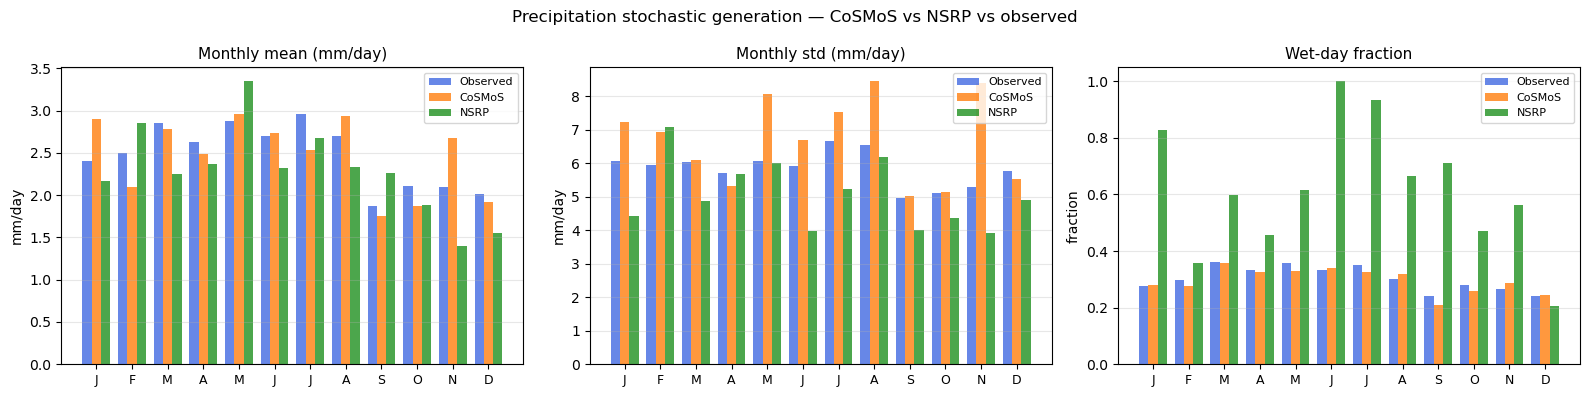

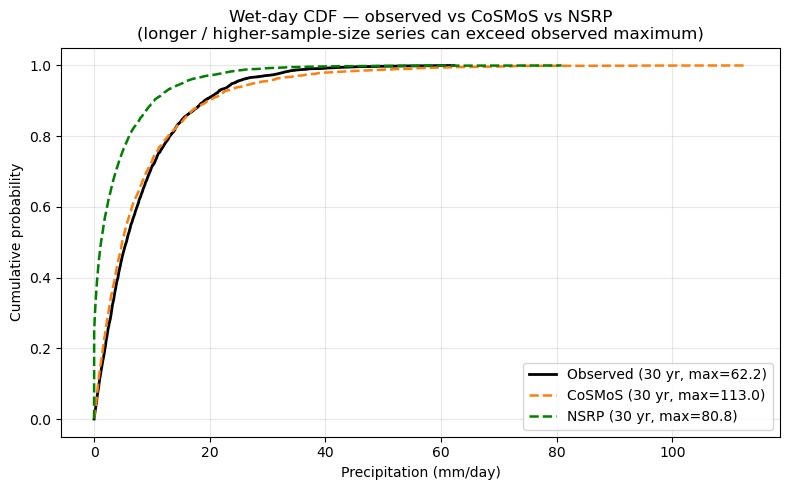

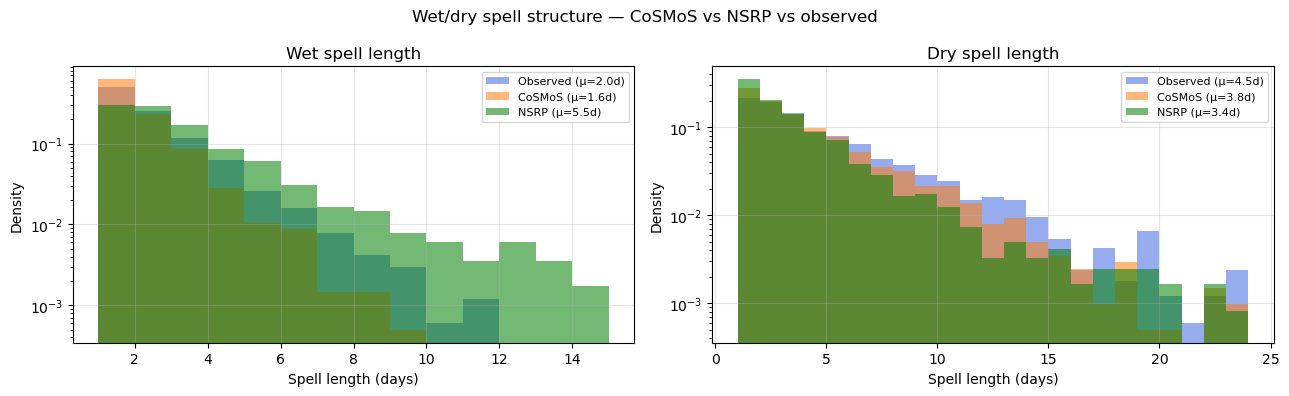


── Summary: CoSMoS vs NSRP — precipitation ─────────────────
Statistic                      Observed     CoSMoS       NSRP
--------------------------------------------------------------
Annual mean (mm/day)               2.48       2.47       2.28
Annual std (mm/day)                5.87       6.82       5.16
Wet-day fraction                   0.30       0.30       0.62
Max daily (mm/day)                 62.2      113.0       80.8
Mean wet spell (days)               2.0        1.6        5.5
Mean dry spell (days)               4.5        3.8        3.4


In [16]:
import warnings

months = list(range(1, 13))
lbl    = ["J","F","M","A","M","J","J","A","S","O","N","D"]
x      = np.arange(12)

# ═══════════════════════════════════════════════════════════════════
# A. CoSMoS fitted to precipitation (P_obs)
# ═══════════════════════════════════════════════════════════════════
# analyze_ts handles p0 (zero probability) automatically from the data.
print("Fitting CoSMoS seasonal model to precipitation ...")
ts_stats_p = analyze_ts(P_obs, dist='gengamma', acs_id='weibull')
stats_df_p = report_ts(ts_stats_p)
print("Done.\n")
print("CoSMoS seasonal model — precipitation:")
print(stats_df_p[['dist', 'mean', 'sd', 'p0', 'acs.l.2']].to_string())

# CoSMoS 30-year realisation
sim_cosmos = simulate_ts(ts_stats_p, from_date="1990-01-01", to_date="2019-12-31")
sim_cosmos_s = sim_cosmos.set_index("date")["value"].clip(lower=0)

# ═══════════════════════════════════════════════════════════════════
# B. NSRP 100-year simulation — use first 30 years for comparison
# ═══════════════════════════════════════════════════════════════════
sim_nsrp = sim_s.loc[sim_s.index.year <= sim_s.index.year[0] + 29]

# ── Helper: spell length distribution ────────────────────────────
def _spells(arr_values, is_wet):
    arr = np.asarray(arr_values) > 0
    if not is_wet:
        arr = ~arr
    runs, count = [], 0
    for v in arr:
        if v:
            count += 1
        else:
            if count > 0:
                runs.append(count)
            count = 0
    if count > 0:
        runs.append(count)
    return np.array(runs) if runs else np.array([0])

# ── Monthly statistics ────────────────────────────────────────────
obs_mean = np.array([P_obs[P_obs.index.month == m].mean() for m in months])
obs_std  = np.array([P_obs[P_obs.index.month == m].std()  for m in months])
obs_wet  = np.array([(P_obs[P_obs.index.month == m] > 0).mean() for m in months])

cos_mean = np.array([sim_cosmos_s[sim_cosmos_s.index.month == m].mean() for m in months])
cos_std  = np.array([sim_cosmos_s[sim_cosmos_s.index.month == m].std()  for m in months])
cos_wet  = np.array([(sim_cosmos_s[sim_cosmos_s.index.month == m] > 0).mean() for m in months])

nsp_mean = np.array([sim_nsrp[sim_nsrp.index.month == m].mean() for m in months])
nsp_std  = np.array([sim_nsrp[sim_nsrp.index.month == m].std()  for m in months])
nsp_wet  = np.array([(sim_nsrp[sim_nsrp.index.month == m] > 0).mean() for m in months])

# ── Figure 1: monthly statistics — 3 side-by-side panels ─────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
w = 0.26
for ax, obs_v, cos_v, nsp_v, title, ylabel in zip(
    axes,
    [obs_mean, obs_std, obs_wet],
    [cos_mean, cos_std, cos_wet],
    [nsp_mean, nsp_std, nsp_wet],
    ["Monthly mean (mm/day)", "Monthly std (mm/day)", "Wet-day fraction"],
    ["mm/day", "mm/day", "fraction"],
):
    ax.bar(x - w, obs_v, w, color="royalblue", alpha=0.8, label="Observed")
    ax.bar(x,     cos_v, w, color="C1",        alpha=0.8, label="CoSMoS")
    ax.bar(x + w, nsp_v, w, color="green",     alpha=0.7, label="NSRP")
    ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
if axes[2].get_ylim()[1] > 1.1:
    axes[2].set_ylim(0, 1.05)

plt.suptitle("Precipitation stochastic generation — CoSMoS vs NSRP vs observed", fontsize=12)
plt.tight_layout(); plt.show()

# ── Figure 2: wet-day CDF ─────────────────────────────────────────
obs_w  = np.sort(P_obs[P_obs > 0].values)
cos_w  = np.sort(sim_cosmos_s[sim_cosmos_s > 0].values)
nsp_w  = np.sort(sim_nsrp[sim_nsrp > 0].values)
p_obs  = np.arange(1, len(obs_w)+1) / (len(obs_w)+1)
p_cos  = np.arange(1, len(cos_w)+1) / (len(cos_w)+1)
p_nsp  = np.arange(1, len(nsp_w)+1) / (len(nsp_w)+1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(obs_w, p_obs, "k-",  lw=2,   label=f"Observed (30 yr, max={obs_w.max():.1f})")
ax.plot(cos_w, p_cos, "C1--", lw=1.8, label=f"CoSMoS (30 yr, max={cos_w.max():.1f})")
ax.plot(nsp_w, p_nsp, "g--",  lw=1.8, label=f"NSRP (30 yr, max={nsp_w.max():.1f})")
ax.set_xlabel("Precipitation (mm/day)"); ax.set_ylabel("Cumulative probability")
ax.set_title("Wet-day CDF — observed vs CoSMoS vs NSRP\n"
             "(longer / higher-sample-size series can exceed observed maximum)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ── Figure 3: wet/dry spell distributions ────────────────────────
obs_ws = _spells(P_obs.values, True);       obs_ds = _spells(P_obs.values, False)
cos_ws = _spells(sim_cosmos_s.values, True); cos_ds = _spells(sim_cosmos_s.values, False)
nsp_ws = _spells(sim_nsrp.values, True);    nsp_ds = _spells(sim_nsrp.values, False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ws_data, ds_data, bins, title in [
    (axes[0], [obs_ws, cos_ws, nsp_ws], None, range(1, 16), "Wet spell length"),
    (axes[1], None, [obs_ds, cos_ds, nsp_ds], range(1, 25), "Dry spell length"),
]:
    series = ws_data if ws_data is not None else ds_data
    labels = ["Observed", "CoSMoS", "NSRP"]
    colors = ["royalblue", "C1", "green"]
    means  = [s.mean() for s in series]
    for data, lbl_n, col, mu in zip(series, labels, colors, means):
        ax.hist(data, bins=bins, density=True, alpha=0.55, color=col, label=f"{lbl_n} (μ={mu:.1f}d)")
    ax.set_xlabel("Spell length (days)"); ax.set_ylabel("Density")
    ax.set_title(title); ax.set_yscale("log"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Wet/dry spell structure — CoSMoS vs NSRP vs observed", fontsize=12)
plt.tight_layout(); plt.show()

# ── Summary table ─────────────────────────────────────────────────
print("\n── Summary: CoSMoS vs NSRP — precipitation ─────────────────")
print(f"{'Statistic':<28} {'Observed':>10} {'CoSMoS':>10} {'NSRP':>10}")
print("-" * 62)
print(f"{'Annual mean (mm/day)':<28} {P_obs.mean():10.2f} {sim_cosmos_s.mean():10.2f} {sim_nsrp.mean():10.2f}")
print(f"{'Annual std (mm/day)':<28} {P_obs.std():10.2f} {sim_cosmos_s.std():10.2f} {sim_nsrp.std():10.2f}")
print(f"{'Wet-day fraction':<28} {(P_obs>0).mean():10.2f} {(sim_cosmos_s>0).mean():10.2f} {(sim_nsrp>0).mean():10.2f}")
print(f"{'Max daily (mm/day)':<28} {P_obs.max():10.1f} {sim_cosmos_s.max():10.1f} {sim_nsrp.max():10.1f}")
print(f"{'Mean wet spell (days)':<28} {obs_ws.mean():10.1f} {cos_ws.mean():10.1f} {nsp_ws.mean():10.1f}")
print(f"{'Mean dry spell (days)':<28} {obs_ds.mean():10.1f} {cos_ds.mean():10.1f} {nsp_ds.mean():10.1f}")